1.04. 데이터 핸들링 - 판다스

In [1]:
import pandas as pd

In [3]:
titanic_df=pd.read_csv('train.csv') #DataFrame으로 로딩
titanic_df.head(3) #DataFrame의 데이터를 3행까지 출력

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [6]:
titanic_df=pd.read_csv('train.csv')
print('titanic 변수 type', type(titanic_df))
titanic_df #Dataframe의 모든 데이터 출력

titanic 변수 type <class 'pandas.core.frame.DataFrame'>


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [7]:
print('Dataframe의 크기',titanic_df.shape) #행과 열을 튜플 형태로 반환

Dataframe의 크기 (891, 12)


In [8]:
titanic_df.info() #info(): 총 데이터 건수, 데이터 타입, Null건수

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
titanic_df.describe() # 칼럼별 숫자형 데이터 값의 n-percentile분포도, 평균값, 최댓값, 최솟값 *숫자형 칼럼의 분포도만 조사

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


count:Not Null인 데이터 건수
std: 표준편차
25%: 25 percentile값

In [10]:
value_counts=titanic_df['Pclass'].value_counts() #Pclass칼럼 값의 분포 확인/많은 건수 순서로 정렬되어 값 반환/Dataframe의 []연산자 내부에 칼럼명을 입력하면 해당 칼럼에 해당하는 Series 객체 반환
print(value_counts)

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [14]:
titanic_pclass=titanic_df['Pclass']
print(type(titanic_pclass)) #Series: Index와 단 하나의 칼럼으로 구성된 데이터 세트

<class 'pandas.core.series.Series'>


In [15]:
titanic_pclass.head() #좌측: Index, 우측: Series의 데이터 값

0    3
1    1
2    3
3    1
4    3
Name: Pclass, dtype: int64

In [18]:
value_counts=titanic_df['Pclass'].value_counts()
print(type(value_counts))
print(value_counts)

<class 'pandas.core.series.Series'>
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [95]:
print('titanic_df 데이터 건수:', titanic_df.shape[0])
print('기본 설정인 dropna=True로 value_counts()')
# value_counts()는 디폴트로 dropna=True이므로 value_counts(dropna=True)와 동일
print(titanic_df['Embarked'].value_counts())
print(titanic_df['Embarked'].value_counts(dropna=False))

titanic_df 데이터 건수: 891
기본 설정인 dropna=True로 value_counts()
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64


In [96]:
#DataFrame과 리스트, 딕셔너리, 넘파이 ndarray 상호 변환
#넘파이 ndarray, 리스트, 딕셔너리를 DataFrame으로 변환하기
import numpy as np

col_name1=['col1']
list1=[1,2,3]
array1=np.array(list1)
print('array1 shape:', array1.shape)

df_list1 = pd.DataFrame(list1, columns=col_name1)
print('1차원 리스트로 만든 DataFrame:\n', df_list1)

df_array1 = pd.DataFrame(array1, columns=col_name1)
print('1차원 ndarray로 만든 DataFrame:\n', df_array1)

array1 shape: (3,)
1차원 리스트로 만든 DataFrame:
    col1
0     1
1     2
2     3
1차원 ndarray로 만든 DataFrame:
    col1
0     1
1     2
2     3


In [97]:
col_name2=['col1', 'col2', 'col3']
list2 = [[1,2,3],[11,12,13]]
array2=np.array(list2)
print('array2 shape:', array2.shape)
df_list2=pd.DataFrame(list2, columns=col_name2)
print('2차원 리스트로 만든 DataFrame:\n', df_list2)
df_array2=pd.DataFrame(list2, columns=col_name2)
print('2차원 ndarray로 만든 DataFrame:\n', df_list2)

array2 shape: (2, 3)
2차원 리스트로 만든 DataFrame:
    col1  col2  col3
0     1     2     3
1    11    12    13
2차원 ndarray로 만든 DataFrame:
    col1  col2  col3
0     1     2     3
1    11    12    13


In [98]:
#딕셔너리를 DataFrame으로 변경
dict={'col1':[1,11], 'col2':[2,22], 'col3':[3,33]}
df_dict=pd.DataFrame(dict)
print('딕셔너리로 만든 DataFrame:\n', df_dict)

딕셔너리로 만든 DataFrame:
    col1  col2  col3
0     1     2     3
1    11    22    33


In [100]:
#DataFrame을 리스트로 변환
array3=df_dict.values
print('df_dict.values 타입:', type(array3), 'df_dict.values shape:', array3.shape)
print(array3)
#DataFrame을 딕셔너리로 변환
dict3 = df_dict.to_dict('list')
print('\n df_dict.to_dict()타입:', type(dict3))
print(dict3)

df_dict.values 타입: <class 'numpy.ndarray'> df_dict.values shape: (2, 3)
[[ 1  2  3]
 [11 22 33]]

 df_dict.to_dict()타입: <class 'dict'>
{'col1': [1, 11], 'col2': [2, 22], 'col3': [3, 33]}


In [101]:
#DataFrame의 칼럼 데이터 세트 생성과 수정
titanic_df['Age_0']=0
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_0
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0


In [104]:
titanic_df['Age_by_10']=titanic_df['Age']*10 #기존 칼럼Series의 데이터를 이용한 새로운 칼럼 Series
titanic_df['Family_No']=titanic_df['SibSp'] + titanic_df['Parch']+1
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_0,Age_by_10,Family_No
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,220.0,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,380.0,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,260.0,1


In [105]:
titanic_df['Age_by_10'] = titanic_df['Age_by_10'] +100
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_0,Age_by_10,Family_No
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,320.0,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,480.0,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,360.0,1


In [106]:
#DataFrame 삭제
titanic_drop_df=titanic_df.drop('Age_0', axis=1) 
titanic_drop_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_by_10,Family_No
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,320.0,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,480.0,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,360.0,1


In [107]:
titanic_df.head(3)#inplace의 디폴트 값이 False(자기 자신의 DataFrame의 데이터는 삭제하지 않으며, 삭제된 결과 DataFrame을 반환)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_0,Age_by_10,Family_No
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,320.0,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,480.0,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,360.0,1


In [108]:
drop_result=titanic_df.drop(['Age_0', 'Age_by_10', 'Family_No'], axis=1, inplace=True)
print('inplace=True로 drop 후 반환된 값:', drop_result)
titanic_df.head(3)

inplace=True로 drop 후 반환된 값: None


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [109]:
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 15)
print('### before axis 0 drop ###')
print(titanic_df.head(3))

titanic_df.drop([0,1,2], axis=0, inplace=True)

print('XXX after axis 0 drop ####')
print(titanic_df.head(3))

### before axis 0 drop ###
   PassengerId  Survived  Pclass            Name     Sex   Age  SibSp  Parch          Ticket     Fare Cabin Embarked
0            1         0       3  Braund, Mr....    male  22.0      1      0       A/5 21171   7.2500   NaN        S
1            2         1       1  Cumings, Mr...  female  38.0      1      0        PC 17599  71.2833   C85        C
2            3         1       3  Heikkinen, ...  female  26.0      0      0  STON/O2. 31...   7.9250   NaN        S
XXX after axis 0 drop ####
   PassengerId  Survived  Pclass            Name     Sex   Age  SibSp  Parch  Ticket     Fare Cabin Embarked
3            4         1       1  Futrelle, M...  female  35.0      1      0  113803  53.1000  C123        S
4            5         0       3  Allen, Mr. ...    male  35.0      0      0  373450   8.0500   NaN        S
5            6         0       3  Moran, Mr. ...    male   NaN      0      0  330877   8.4583   NaN        Q


In [111]:
#Index 객체
##원본 파일 다시 로딩
titanic_df=pd.read_csv('train.csv')
##Index 객체 추출
indexes=titanic_df.index
print(indexes)
#Index 객체를 실제 값 array로 변환
print('Index 객체 array값:\n', indexes.values)

RangeIndex(start=0, stop=891, step=1)
Index 객체 array값:
 [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232

In [112]:
print(type(indexes.values))#index는 데이터를 1차원 array로 가지며 단일 값 반환 및 슬라이싱 가능
print(indexes.values.shape)
print(indexes[:5].values)
print(indexes.values[:5])
print(indexes[6])

<class 'numpy.ndarray'>
(891,)
[0 1 2 3 4]
[0 1 2 3 4]
6


In [113]:
indexes[0] = 5 #한 번 만들어진 Index 객체는 변경 불가

TypeError: Index does not support mutable operations

In [114]:
series_fair= titanic_df['Fare']
print('Fair Series max값:', series_fair.max())
print('Fair Series sum값:', series_fair.sum())
print('sum() Fair Series:', sum(series_fair))
print('Fair Series + 3:\n', (series_fair + 3).head(3))

Fair Series max값: 512.3292
Fair Series sum값: 28693.9493
sum() Fair Series: 28693.9493
Fair Series + 3:
 0    10.2500
1    74.2833
2    10.9250
Name: Fare, dtype: float64


In [115]:
titanic_reset_df = titanic_df.reset_index(inplace=False)#인덱스가 연속된 int 숫자형 데이터가 아닐 경우 다시 이를 연속 int 숫자혀여 데이터로 만들 때 주로 사용
titanic_reset_df.head(3)

,index,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,1,0,3,"Braund, Mr....",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,2,1,1,"Cumings, Mr...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,2,3,1,3,"Heikkinen, ...",female,26.0,0,0,STON/O2. 31...,7.9250,NaN,S


In [116]:
print('### before reset_index ###')
value_counts = titanic_df['Pclass'].value_counts()
print(value_counts)
print('value_counts 객체 변수 타입:', type(value_counts))
new_value_counts = value_counts.reset_index(inplace=False)
print('### After reset_index ###')
print(new_value_counts)
print('new_value_counts 객체 변수 타입:', type(new_value_counts))

### before reset_index ###
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
value_counts 객체 변수 타입: <class 'pandas.core.series.Series'>
### After reset_index ###
   Pclass  count
0       3    491
1       1    216
2       2    184
new_value_counts 객체 변수 타입: <class 'pandas.core.frame.DataFrame'>


데이터 셀렉션 및 필터링

In [117]:
#DataFrame의 []연산자:['칼럼명'], 칼럼지정연산자
print('단일 칼럼 데이터 추출:\n', titanic_df['Pclass']. head(3))
print('\n여러 칼럼의 데이터 추출:\n', titanic_df[['Survived', 'Pclass']].head(3))
print('[] 안에 숫자 index는 keyerror 오류 발생:\n', titanic_df[0])

단일 칼럼 데이터 추출:
 0    3
1    1
2    3
Name: Pclass, dtype: int64

여러 칼럼의 데이터 추출:
    Survived  Pclass
0         0       3
1         1       1
2         1       3


KeyError: 0

In [118]:
titanic_df[0:2] #슬라이싱할 때는 칼럼명이 아닌 숫자를 넣을 수 있음

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr....",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mr...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [119]:
titanic_df[titanic_df['Pclass']==3].head(3) #불린 인덱싱도 표현 가능

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr....",male,22.0,1,0,A/5 21171,7.250,NaN,S
2,3,1,3,"Heikkinen, ...",female,26.0,0,0,STON/O2. 31...,7.925,NaN,S
4,5,0,3,"Allen, Mr. ...",male,35.0,0,0,373450,8.050,NaN,S


In [120]:
#DataFrame iloc()연산자:위치 기반 인덱싱
data={'Name': ['A', 'B','C','D'],
      'Year': ['11','12','13','14'],
      'Gender': ['Male','Female','Male','Male']
     }
data_df = pd.DataFrame(data, index=['one','two','three','four'])
data_df

,Name,Year,Gender
one,A,11,Male
two,B,12,Female
three,C,13,Male
four,D,14,Male


In [121]:
data_df.iloc[0,0]

'A'

In [122]:
data_df.iloc[0,'Name']#위치가 아닌 값을 입력하는 경우 오류 발생

ValueError: Location based indexing can only have [integer, integer slice (START point is INCLUDED, END point is EXCLUDED), listlike of integers, boolean array] types

In [124]:
data_df.iloc['one',0] #인덱스 값인 'one'을 입력하여 오류 발생

ValueError: Location based indexing can only have [integer, integer slice (START point is INCLUDED, END point is EXCLUDED), listlike of integers, boolean array] types

In [123]:
print("\n 맨 마지막 칼럼 데이터 [:,-1] \n", data_df.iloc[:,-1])#맨 마지막 칼럼 데이터
print("\n 맨 마지막 칼럼을 제외한 모든 데이터 [:, :-1]\n", data_df.iloc[:,:-1])#맨 마지막을 제외한 칼럼 데이터


 맨 마지막 칼럼 데이터 [:,-1] 
 one        Male
two      Female
three      Male
four       Male
Name: Gender, dtype: object

 맨 마지막 칼럼을 제외한 모든 데이터 [:, :-1]
       Name Year
one      A   11
two      B   12
three    C   13
four     D   14


In [125]:
#loc[]연산자: 명칭(label)기반 인덱싱
data_df.loc['one', 'Name']

'A'

In [126]:
data_df.loc[0,'Name'] #명칭이 아닌 값을 넣는 경우 오류 발생

KeyError: 0

In [ ]:
print('위치기반 iloc slicing\n', data_df.iloc[0:1,0],'\n')#loc에서 :는 시작값~(종료값-1)이 아니라 시작값부터 종료값까지를 말한다.
print('위치기반 loc slicing\n', data_df.loc['one':'two', 'Name'])

In [128]:
#불린 인덱싱
titanic_df=pd.read_csv('train.csv')
titanic_boolean = titanic_df[titanic_df['Age'] >60]
print(type(titanic_boolean))
titanic_boolean

<class 'pandas.core.frame.DataFrame'>


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr...",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
54,55,0,1,"Ostby, Mr. ...",male,65.0,0,1,113509,61.9792,B30,C
96,97,0,1,Goldschmidt...,male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr...",male,70.5,0,0,370369,7.7500,NaN,Q
170,171,0,1,Van der hoe...,male,61.0,0,0,111240,33.5000,B19,S
252,253,0,1,"Stead, Mr. ...",male,62.0,0,0,113514,26.5500,C87,S
275,276,1,1,"Andrews, Mi...",female,63.0,1,0,13502,77.9583,D7,S
280,281,0,3,"Duane, Mr. ...",male,65.0,0,0,336439,7.7500,NaN,Q
326,327,0,3,"Nysveen, Mr...",male,61.0,0,0,345364,6.2375,NaN,S
438,439,0,1,"Fortune, Mr...",male,64.0,1,4,19950,263.0000,C23 C25 C27,S


In [129]:
titanic_df[titanic_df['Age']>60][['Name','Age']].head(3)

,Name,Age
33,"Wheadon, Mr...",66.0
54,"Ostby, Mr. ...",65.0
96,Goldschmidt...,71.0


In [130]:
titanic_df[(titanic_df['Age']>60)&(titanic_df['Pclass']==1)&
    (titanic_df['Sex']=='female')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
275,276,1,1,"Andrews, Mi...",female,63.0,1,0,13502,77.9583,D7,S
829,830,1,1,"Stone, Mrs....",female,62.0,0,0,113572,80.0000,B28,NaN


In [132]:
cond1=titanic_df['Age']>60
cond2=titanic_df['Pclass']==1
cond3=titanic_df['Sex']=='female'
titanic_df[cond1&cond2&cond3]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,1,"Wheadon, Mr...",female,66.0,0,0,C.A. 24579,10.5000,NaN,S
54,55,0,1,"Ostby, Mr. ...",female,65.0,0,1,113509,61.9792,B30,C
96,97,0,1,Goldschmidt...,female,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,1,"Connors, Mr...",female,70.5,0,0,370369,7.7500,NaN,Q
170,171,0,1,Van der hoe...,female,61.0,0,0,111240,33.5000,B19,S
252,253,0,1,"Stead, Mr. ...",female,62.0,0,0,113514,26.5500,C87,S
275,276,1,1,"Andrews, Mi...",female,63.0,1,0,13502,77.9583,D7,S
280,281,0,1,"Duane, Mr. ...",female,65.0,0,0,336439,7.7500,NaN,Q
326,327,0,1,"Nysveen, Mr...",female,61.0,0,0,345364,6.2375,NaN,S
438,439,0,1,"Fortune, Mr...",female,64.0,1,4,19950,263.0000,C23 C25 C27,S


정렬,Aggregation함수,Groupby 적용

In [133]:
#DataFrame,Series의 정렬-sort_values()
titanic_sorted=titanic_df.sort_values(by=['Name'])#Name칼럼으로 오름차순 정렬해 반환
titanic_sorted.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
845,846,0,1,"Abbing, Mr....",female,42.0,0,0,C.A. 5547,7.55,NaN,S
746,747,0,1,"Abbott, Mr....",female,16.0,1,1,C.A. 2673,20.25,NaN,S
279,280,1,1,"Abbott, Mrs...",female,35.0,1,1,C.A. 2673,20.25,NaN,S


In [ ]:
titanic_sorted=titanic_df.sort_values(by=['Pclass', 'Name'], ascending=False)#두 개 이상인 경우 먼저 온 것부터 내림차순 진행
titanic_sorted.head(3)

In [134]:
#Aggregation 함수 적용
titanic_df.count()

PassengerId    891
Survived       891
Pclass         891
Name           891
Sex            891
Age            714
SibSp          891
Parch          891
Ticket         891
Fare           891
Cabin          204
Embarked       889
dtype: int64

In [135]:
titanic_df[['Age','Fare']].mean

<bound method DataFrame.mean of       Age     Fare
0    22.0   7.2500
1    38.0  71.2833
2    26.0   7.9250
3    35.0  53.1000
4    35.0   8.0500
..    ...      ...
886  27.0  13.0000
887  19.0  30.0000
888   NaN  23.4500
889  26.0  30.0000
890  32.0   7.7500

[891 rows x 2 columns]>

In [136]:
#Groupby:칼럼을 기준으로 groupby
titanic_groupby = titanic_df.groupby(by='Pclass')
print(type(titanic_groupby))

<class 'pandas.core.groupby.generic.DataFrameGroupBy'>


In [137]:
titanic_groupby = titanic_df.groupby('Pclass').count()
titanic_groupby

,PassengerId,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Pclass,,,,,,,,,,,
1,891,891,891,891,714,891,891,891,891,204,889


In [138]:
titanic_groupby = titanic_df.groupby('Pclass')[['PassengerId','Survived']].count()
titanic_groupby

,PassengerId,Survived
Pclass,,
1,891,891


In [139]:
titanic_df.groupby('Pclass')['Age'].agg([max,min])

C:\Users\kimsh\AppData\Local\Temp\ipykernel_4580\414103430.py:1: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  titanic_df.groupby('Pclass')['Age'].agg([max,min])
C:\Users\kimsh\AppData\Local\Temp\ipykernel_4580\414103430.py:1: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  titanic_df.groupby('Pclass')['Age'].agg([max,min])


,max,min
Pclass,,
1,80.0,0.42


In [140]:
agg_format={'Age':'max', 'SibSp':'sum', 'Fare':'mean'}
titanic_df.groupby('Pclass').agg(agg_format) #groupby 해제

,Age,SibSp,Fare
Pclass,,,
1,80.0,466,32.204208


결손 데이터 처리하기

In [141]:
#isna()로 결손 데이터 여부 확인
titanic_df.isna().head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False


In [142]:
titanic_df.isna().sum()#결손 데이터 개수

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [143]:
#fillna()로 결손 데이터 대체하기
titanic_df['Cabin']=titanic_df['Cabin'].fillna('C000')
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,1,"Braund, Mr....",female,22.0,1,0,A/5 21171,7.2500,C000,S
1,2,1,1,"Cumings, Mr...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,1,"Heikkinen, ...",female,26.0,0,0,STON/O2. 31...,7.9250,C000,S


In [144]:
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].mean())
titanic_df['Embarked'] = titanic_df['Embarked'].fillna('S')
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,1,"Braund, Mr....",female,22.000000,1,0,A/5 21171,7.2500,C000,S
1,2,1,1,"Cumings, Mr...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,1,"Heikkinen, ...",female,26.000000,0,0,STON/O2. 31...,7.9250,C000,S
3,4,1,1,"Futrelle, M...",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,1,"Allen, Mr. ...",female,35.000000,0,0,373450,8.0500,C000,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,1,"Montvila, R...",female,27.000000,0,0,211536,13.0000,C000,S
887,888,1,1,"Graham, Mis...",female,19.000000,0,0,112053,30.0000,B42,S
888,889,0,1,"Johnston, M...",female,29.699118,1,2,W./C. 6607,23.4500,C000,S
889,890,1,1,"Behr, Mr. K...",female,26.000000,0,0,111369,30.0000,C148,C


apply lambda 식으로 데이터 가공

In [145]:
def get_square(a):
    return a**2

print('3의 제곱은:', get_square(3))

3의 제곱은: 9


In [147]:
lambda_square = lambda x : x**2
print('3의 제곱은:', lambda_square(3))

3의 제곱은: 9


In [148]:
a=[1,2,3]
squares = map(lambda x : x**2, a) #map()여러 개의 값을 입력 인자로 사용해야하는 경우 사용
list(squares)

[1, 4, 9]

In [149]:
titanic_df['Name_len']=titanic_df['Name'].apply(lambda x : len(x))
titanic_df[['Name', 'Name_len']].head(3)

,Name,Name_len
0,"Braund, Mr....",23
1,"Cumings, Mr...",51
2,"Heikkinen, ...",22


In [150]:
titanic_df['Child_Adult'] = titanic_df['Age'].apply(lambda x : 'Child' if x <= 15 else 'Adult')
titanic_df[['Age', 'Child_Adult']].head(8)

,Age,Child_Adult
0,22.000000,Adult
1,38.000000,Adult
2,26.000000,Adult
3,35.000000,Adult
4,35.000000,Adult
5,29.699118,Adult
6,54.000000,Adult
7,2.000000,Child


In [151]:
titanic_df['Age_cat'] = titanic_df['Age'].apply(lambda x : 'Child' if x<=15 else ('Adult' if x <= 60
                                                                                  else 'Elderly'))
titanic_df['Age_cat'].value_counts() #else if 는 지원하지 않는다.

Age_cat
Adult      786
Child       83
Elderly     22
Name: count, dtype: int64

chater 10. 시각화 

01. 맷플롯립과 시본 개요
-Matplotlib:시각화 라이브러리
-Seaborn: Matplotlib보다 구현이 쉬우며 판다스와의 연동이 장점

02. Matplotlib

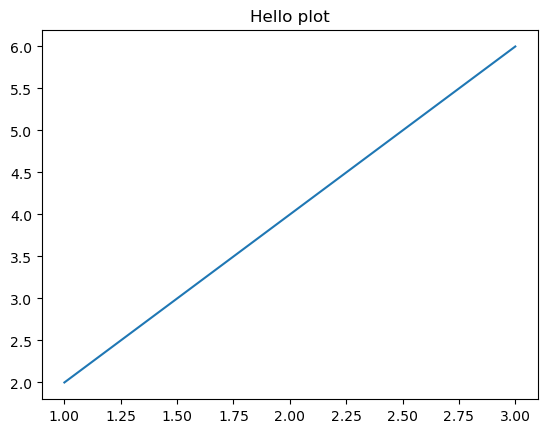

In [3]:
import matplotlib.pyplot as plt #pyplot: plot() 함수를 통해 선 그래프를 그림

plt.plot([1,2,3],[2,4,6]) #x축, y축

plt.title("Hello plot")

plt.show()

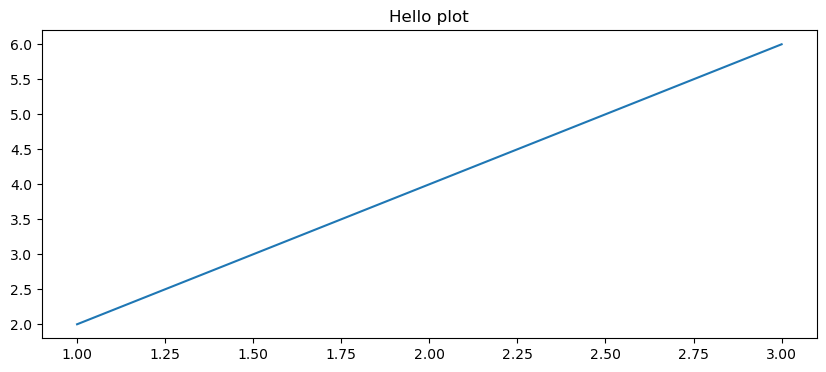

In [5]:
#Figure과 Axes
#Figure: 그림판의 크기 조절
#Axes: axes 객체 기반에서 시각화 작업 진행

plt.figure(figsize=(10,4))

plt.plot([1,2,3],[2,4,6])
plt.title("Hello plot")
plt.show()

In [6]:
figure=plt.figure(figsize=(10,4))
print(type(figure))

<class 'matplotlib.figure.Figure'>


<Figure size 1000x400 with 0 Axes>

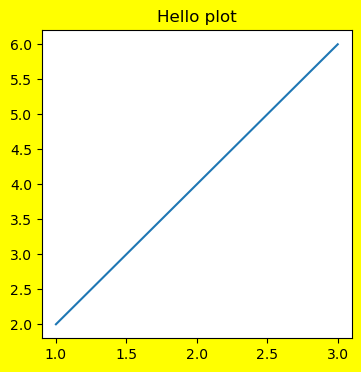

In [7]:
plt.figure(figsize=(4,4),facecolor='yellow') #배경 색 변경 가능 with Figure
plt.plot([1,2,3],[2,4,6])
plt.title("Hello plot")
plt.show()

<class 'matplotlib.axes._axes.Axes'>


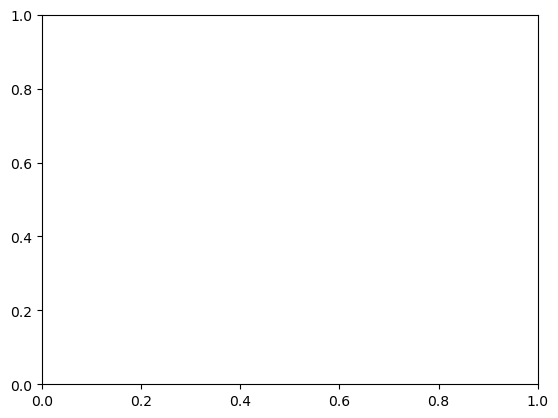

In [9]:
ax=plt.axes()
print(type(ax))

fig type: <class 'matplotlib.figure.Figure'> 
ax type: <class 'matplotlib.axes._axes.Axes'>


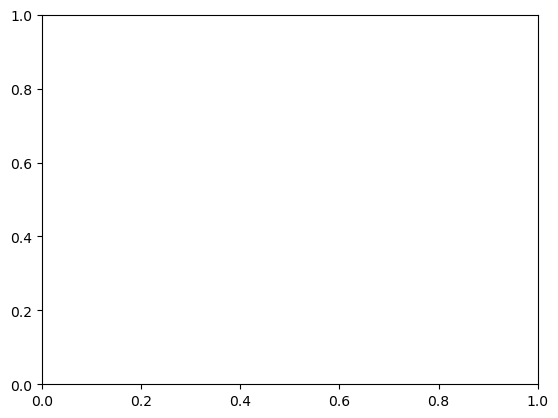

In [10]:
fig,ax=plt.subplots() # subplots(): figure,axes 객체 함께 가져올 때
print('fig type:',type(fig),'\nax type:',type(ax))

<function matplotlib.pyplot.show(close=None, block=None)>

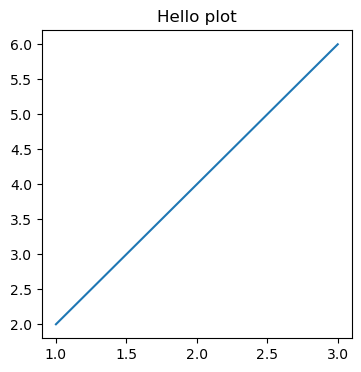

In [12]:
fig,ax=plt.subplots(figsize=(4,4))

ax.plot([1,2,3],[2,4,6]) #Axes 객체를 바로 이용함

ax.set_title('Hello plot')
plt.show

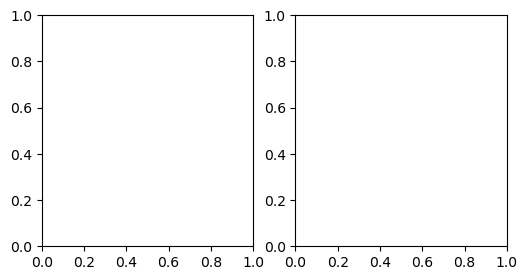

In [13]:
# 여러 개의 plot을 갖는 subplot 생성

fig,(ax1,ax2)=plt.subplots(nrows=1,ncols=2,figsize=(6,3)) #열 방향으로 두 개 배치

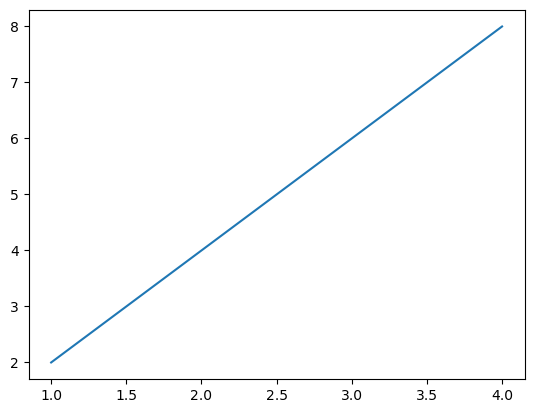

In [15]:
#pyplot의 plot() 함수를 이용한 선 그래프 그리기
import numpy as np
import pandas as pd

x_value=[1,2,3,4]
y_value=[2,4,6,8]

plt.plot(x_value,y_value)
plt.show()

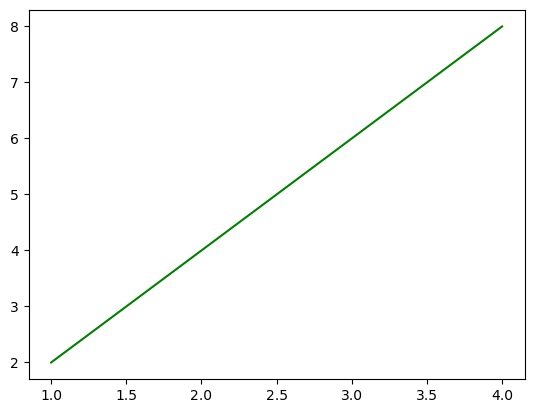

In [16]:
plt.plot(x_value,y_value,color='green') #plot()함수는 color인자를 통해 선 색 변경 가능

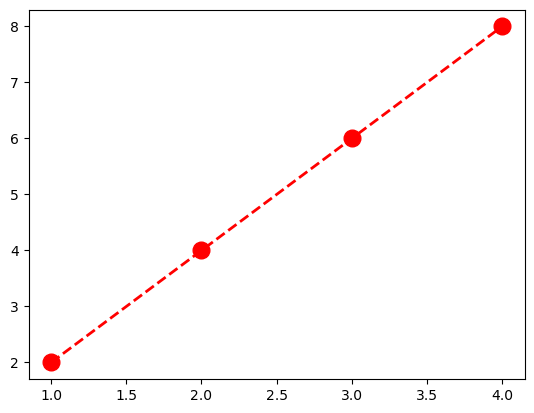

In [17]:
plt.plot(x_value,y_value,color='red',marker='o',linestyle='dashed',linewidth=2,markersize=12)

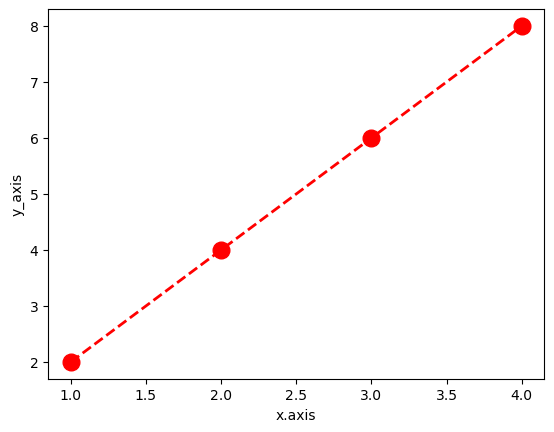

In [18]:
#축 명칭 설정, 축의 눈금(틱)값 회전, 범례 설정하기
plt.plot(x_value,y_value,color='red',marker='o',linestyle='dashed',linewidth=2,markersize=12)

plt.xlabel('x.axis')
plt.ylabel('y_axis')
plt.show()

Text(0, 0.5, 'y_axis')

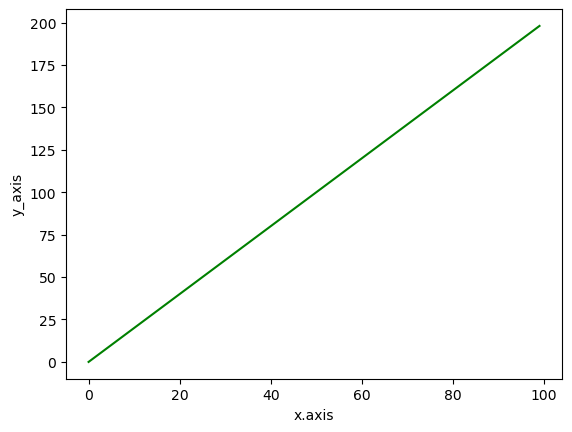

In [19]:
x_value=np.arange(0,100)
y_value=2*x_value

plt.plot(x_value,y_value,color='green')
plt.xlabel('x.axis')
plt.ylabel('y_axis')

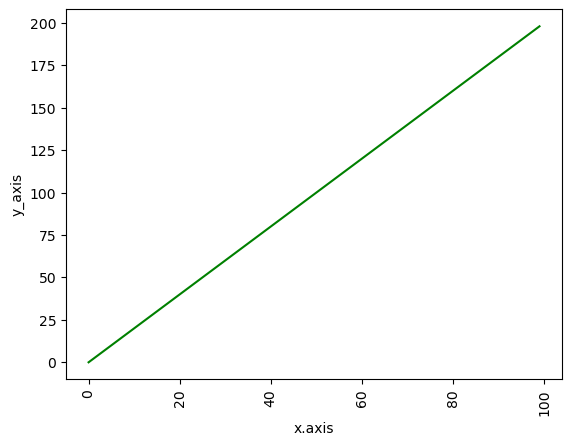

In [21]:
x_value=np.arange(0,100)
y_value=2*x_value

plt.plot(x_value,y_value,color='green')
plt.xlabel('x.axis')
plt.ylabel('y_axis')
plt.xticks(rotation=90) #눈금값 회전
plt.show()

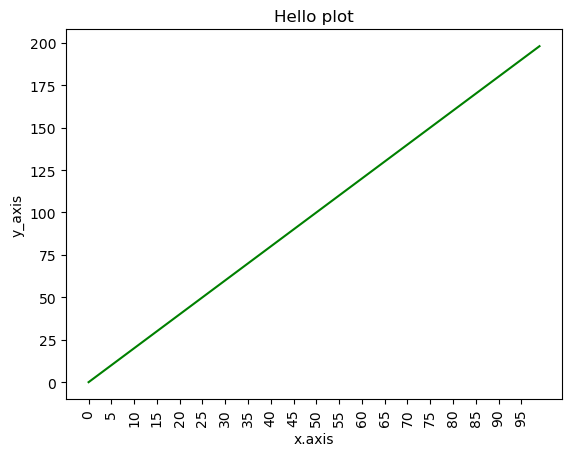

In [22]:
x_value=np.arange(0,100)
y_value=2*x_value

plt.plot(x_value,y_value,color='green')
plt.xlabel('x.axis')
plt.ylabel('y_axis')

plt.xticks(ticks=np.arange(0,100,5),rotation=90) #0부터 99까지 5 스텝으로 20개 표시하고 90도 회전

plt.title('Hello plot')
plt.show()

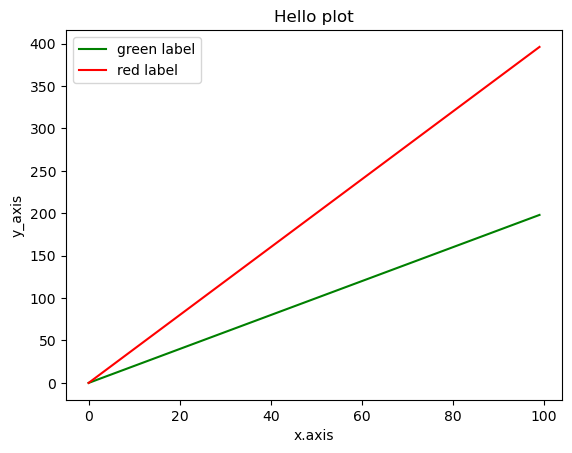

In [24]:
x_value_01=np.arange(0,100)
y_value_01=2*x_value_01
y_value_02=4*x_value_01

plt.plot(x_value_01,y_value_01,color='green',label='green label')
plt.plot(x_value_01,y_value_02,color='red',label='red label')
plt.xlabel('x.axis')
plt.ylabel('y_axis')

plt.legend()# 개별 plot의 label로 설정된 문자열을 범례로 표시

plt.title('Hello plot')
plt.show()

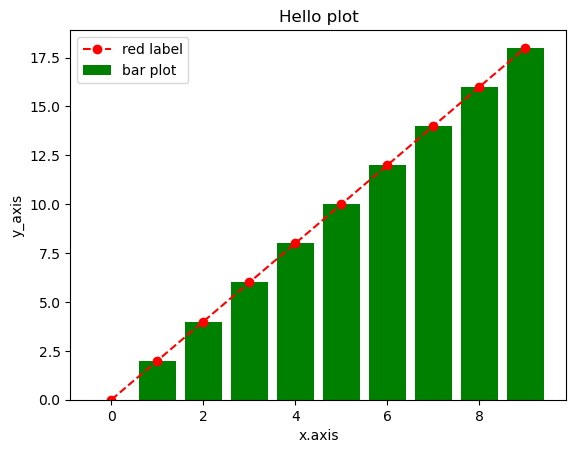

In [25]:
x_value_01=np.arange(0,10)
y_value_01=2*x_value_01

plt.plot(x_value_01,y_value_01,color='red',marker='o',linestyle='dashed',label='red label')
plt.bar(x_value_01,y_value_01,color='green',label='bar plot')

plt.xlabel('x.axis')
plt.ylabel('y_axis')

plt.legend()
plt.title('Hello plot')
plt.show()

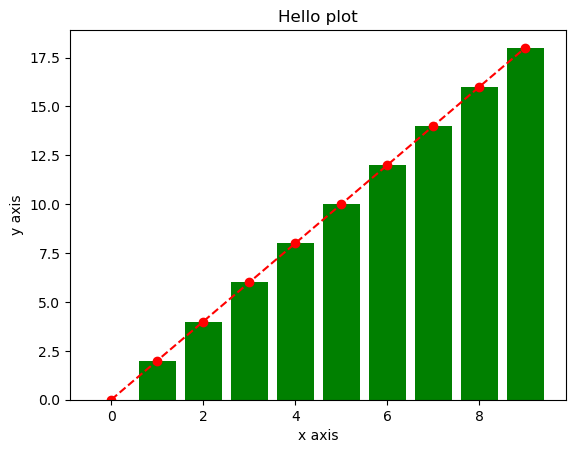

In [26]:
figure=plt.figure()
ax=plt.axes() #Axes객체 메서드 사용
ax.plot(x_value_01,y_value_01,color='red',marker='o',linestyle='dashed',label='red label')
ax.bar(x_value_01,y_value_01,color='green',label='bar plot')

ax.set_xlabel('x axis')
ax.set_ylabel('y axis')

ax.legend
ax.set_title('Hello plot')

plt.show()

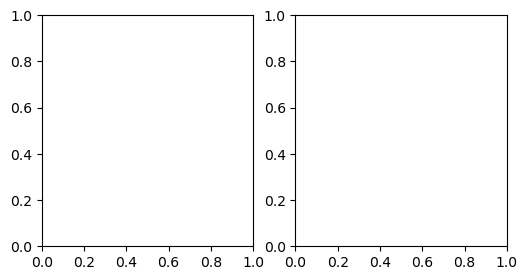

In [29]:
#여러 개의 subplots들을 이용해 개별 그래프들을 subplot별로 시각화하기

fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(6,3))

In [31]:
print('ax type:',type(ax))
print('ax[0] type:',type(ax[0]))
print('ax[1] type:',type(ax[1]))

ax type: <class 'numpy.ndarray'>
ax[0] type: <class 'matplotlib.axes._axes.Axes'>
ax[1] type: <class 'matplotlib.axes._axes.Axes'>


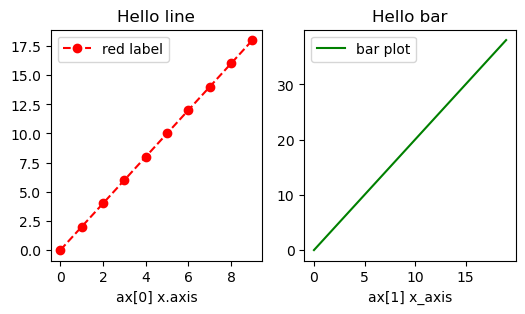

In [35]:
import numpy as np

x_value_01=np.arange(0,10)
x_value_02=np.arange(0,20)
y_value_01=2*x_value_01
y_value_02=2*x_value_02

fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(6,3)) 

#여러 개의 subplots를 이용해 구현할 때는 개별 Axes 객체를 직접 이용해야한다.
ax[0].plot(x_value_01,y_value_01,color='red',marker='o',linestyle='dashed',label='red line')
ax[1].plot(x_value_02,y_value_02,color='green',label='bar plot')

ax[0].set_xlabel('ax[0] x.axis')
ax[1].set_xlabel('ax[1] x_axis')

ax[0].legend()
ax[1].legend()

ax[0].set_title('Hello line')
ax[1].set_title('Hello bar')

plt.show()

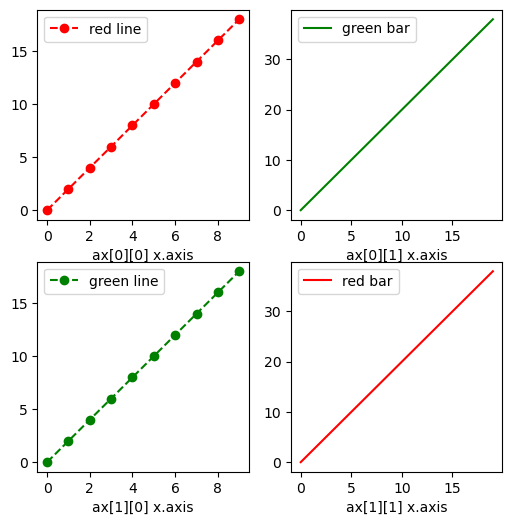

In [36]:
import numpy as np

x_value_01=np.arange(0,10)
x_value_02=np.arange(0,20)
y_value_01=2*x_value_01
y_value_02=2*x_value_02

fig,ax=plt.subplots(nrows=2,ncols=2,figsize=(6,6)) 

ax[0][0].plot(x_value_01,y_value_01,color='red',marker='o',linestyle='dashed',label='red line')
ax[0][1].plot(x_value_02,y_value_02,color='green',label='green bar')
ax[1][0].plot(x_value_01,y_value_01,color='green',marker='o',linestyle='dashed',label='green line')
ax[1][1].plot(x_value_02,y_value_02,color='red',label='red bar')

ax[0][0].set_xlabel('ax[0][0] x.axis')
ax[0][1].set_xlabel('ax[0][1] x.axis')
ax[1][0].set_xlabel('ax[1][0] x.axis')
ax[1][1].set_xlabel('ax[1][1] x.axis')

ax[0][0].legend()
ax[0][1].legend()
ax[1][0].legend()
ax[1][1].legend()

plt.show()

03.Seaborn

In [39]:
import pandas as pd

titanic_df=pd.read_csv('train.csv')
titanic_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


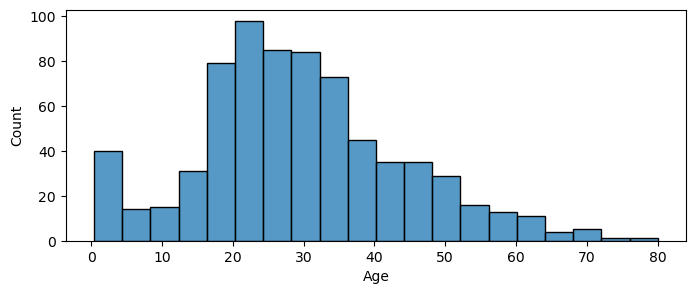

In [42]:
#히스토그램: 연속형 값의 건수를 막대 그래프 형태로 시각화

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,3))

sns.histplot(titanic_df['Age'],bins=20) #bins:구간의 개수
plt.show()

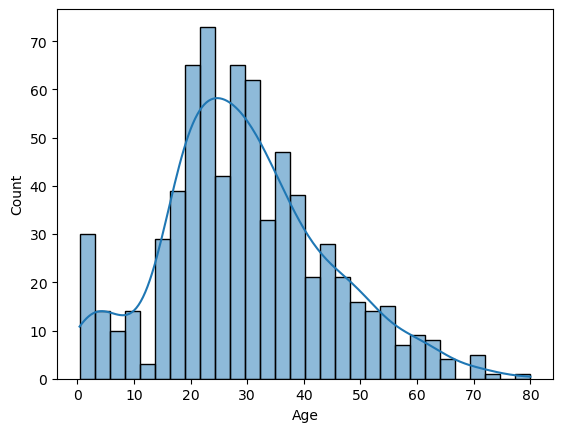

In [43]:
sns.histplot(x='Age',data=titanic_df,bins=30,kde=True) #kde=True: 연속 확률분 곡선 그려줌
plt.show()

<Figure size 800x400 with 0 Axes>

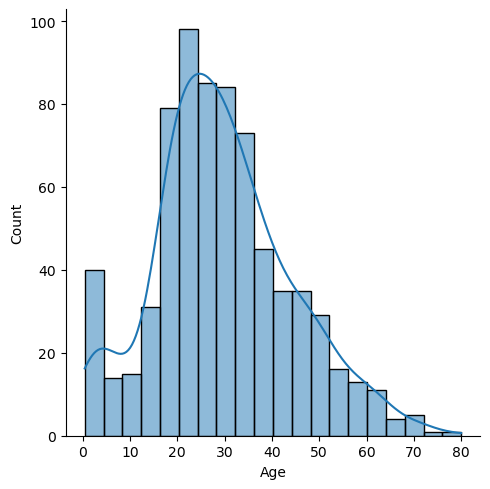

In [51]:
import seaborn as sns

plt.figure(figsize=(8,4))# 시본의 레벨 함수를 사용하면 plt.figure()를 이용해 크기 조절할 수 없음
sns.displot(x='Age',data=titanic_df,kde=True)
plt.show()

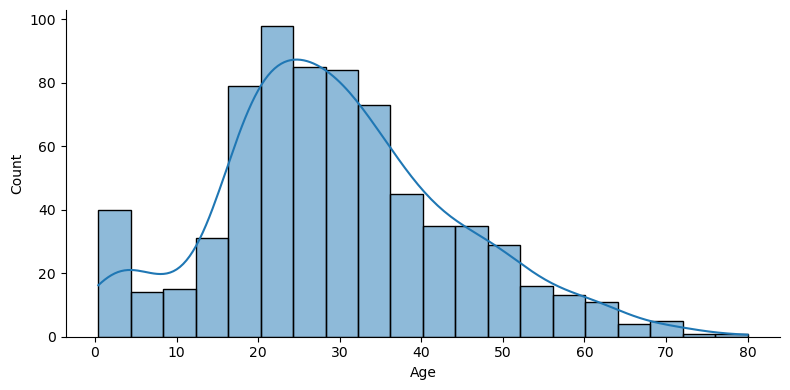

In [50]:
import seaborn as sns

sns.displot(titanic_df['Age'],kde=True,height=4,aspect=2) #height:세로, aspect:가로
plt.show()

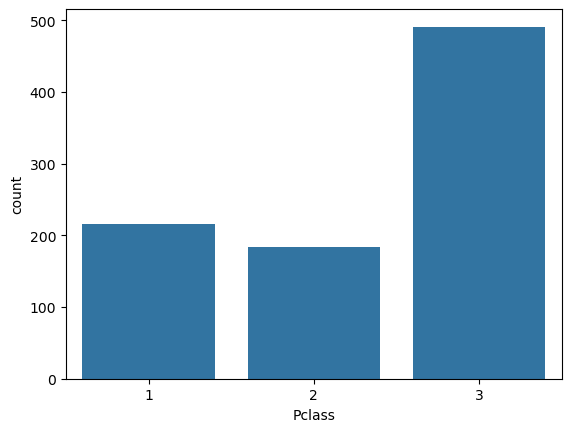

In [52]:
#카운트 플롯 : 이산형 값의 건수를 막대 그래프 형태로 시각화
sns.countplot(x='Pclass',data=titanic_df)
plt.show()

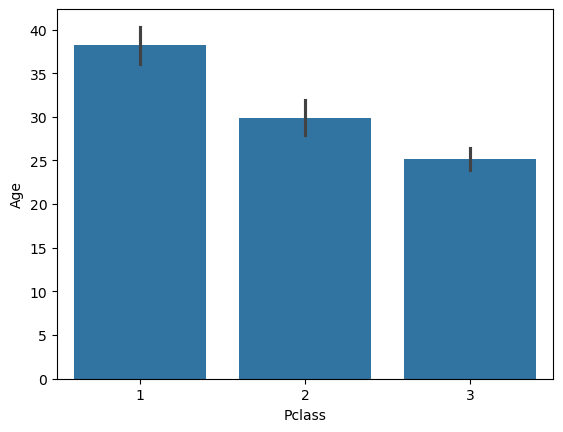

In [53]:
#바 플롯: 2차원 축 기밥ㄴ의 시각화에 널리 활용

sns.barplot(x='Pclass',y='Age',data=titanic_df)
plt.show()

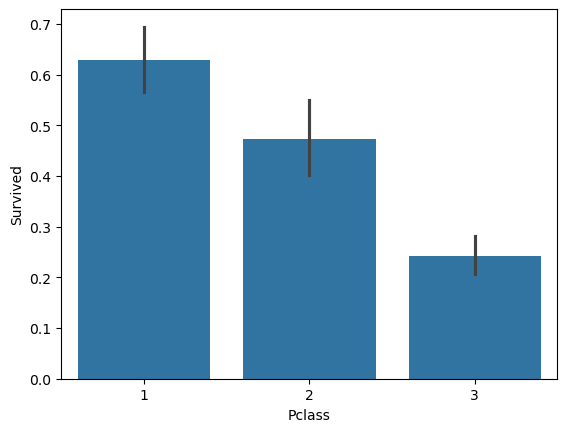

In [55]:
sns.barplot(x='Pclass',y='Survived',data=titanic_df) #평균값으로 계산
plt.show()

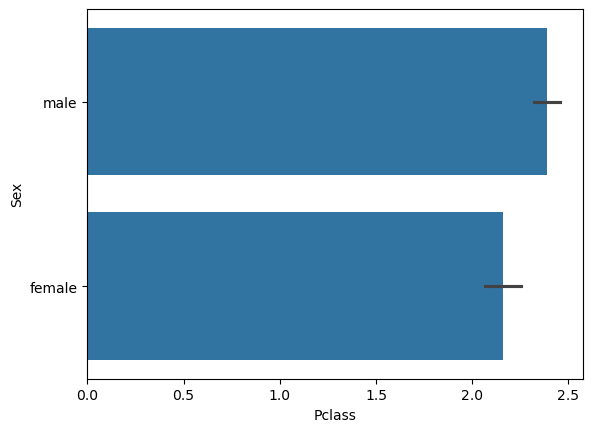

In [59]:
sns.barplot(x='Pclass',y='Sex',data=titanic_df) #y축을 문자값으로 설정하면 자동으로 수평 막대 그래프 변환
plt.show()

In [60]:
sns.barplot(x='names',y='Sex',data=titanic_df) #x,y축을 모두 문자값으로 설정하면 오류 메세지 출력
plt.show()

ValueError: Could not interpret value `names` for `x`. An entry with this name does not appear in `data`.

C:\Users\kimsh\AppData\Local\Temp\ipykernel_4580\248691700.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Pclass',y='Survived',data=titanic_df,ci=None,estimator=sum)


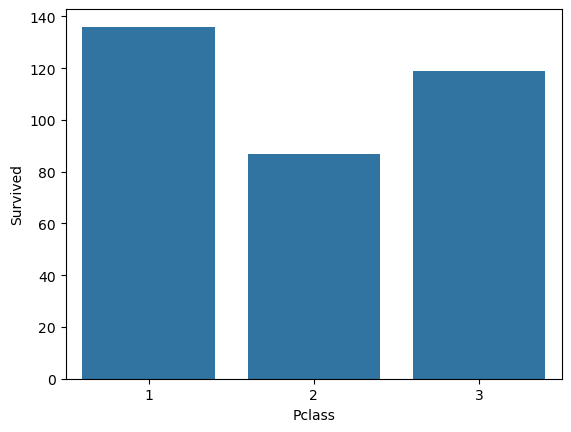

In [61]:
sns.barplot(x='Pclass',y='Survived',data=titanic_df,ci=None,estimator=sum) #estimator = 막대 높이를 계산하는 방식,ci = 오차막대 표시 여부
plt.show()

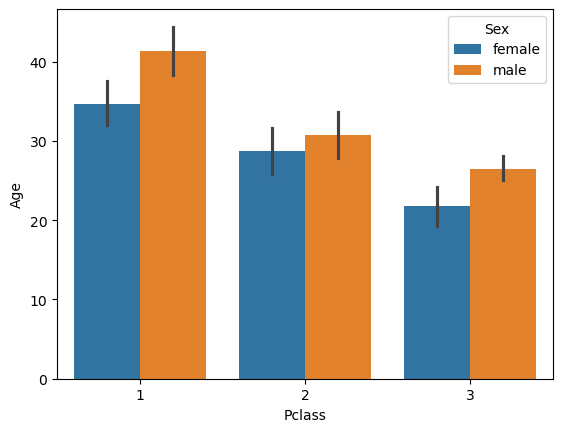

In [62]:
#barplot()함수의 hue 인자를 사용하여 시각화 정보를 추가적으로 세분화하기
sns.barplot(x='Pclass',y='Age',hue='Sex',data=titanic_df)
plt.show()

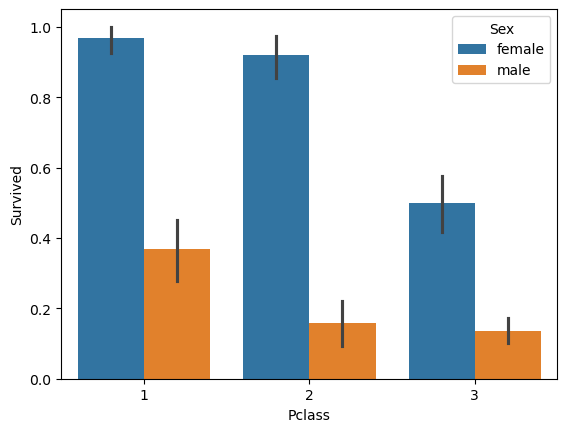

In [63]:
sns.barplot(x='Pclass',y='Survived',hue='Sex',data=titanic_df)
plt.show()

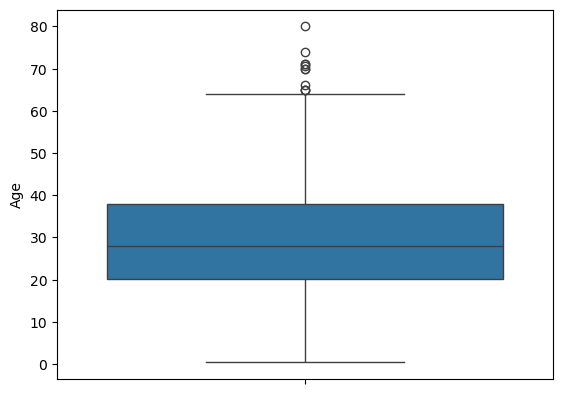

In [69]:
#박스플롯
sns.boxplot(y='Age',data=titanic_df)
plt.show()

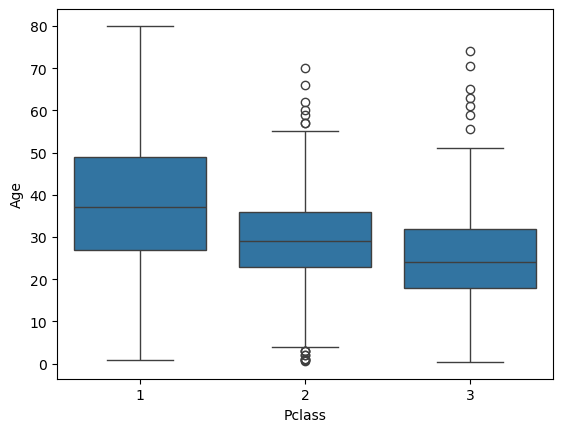

In [71]:
sns.boxplot(x='Pclass',y='Age',data=titanic_df)
plt.show()

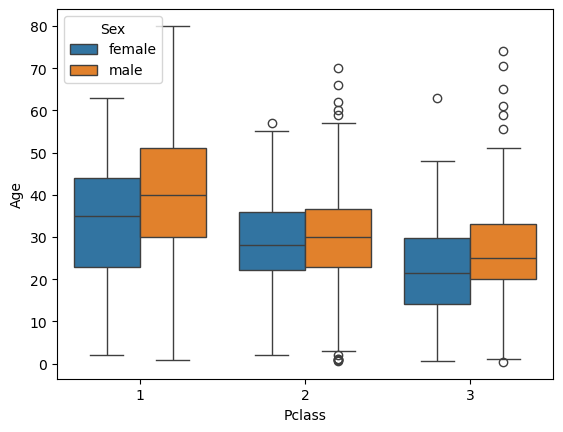

In [73]:
sns.boxplot(x='Pclass',y='Age',hue='Sex',data=titanic_df)
plt.show()

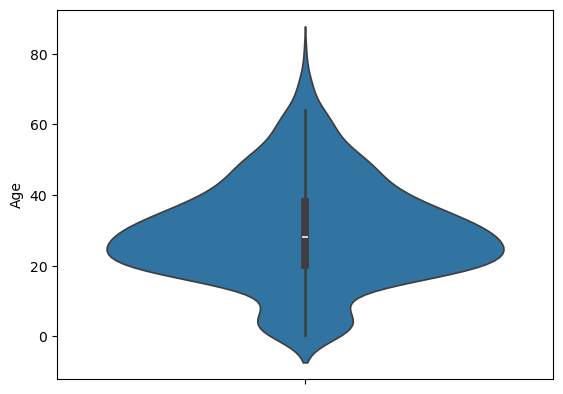

In [74]:
#바이올린 플롯:히스토그램의 연속 확률 분포 곡선과 박스 플롯을 함께 시각화
sns.violinplot(y='Age',data=titanic_df)
plt.show()

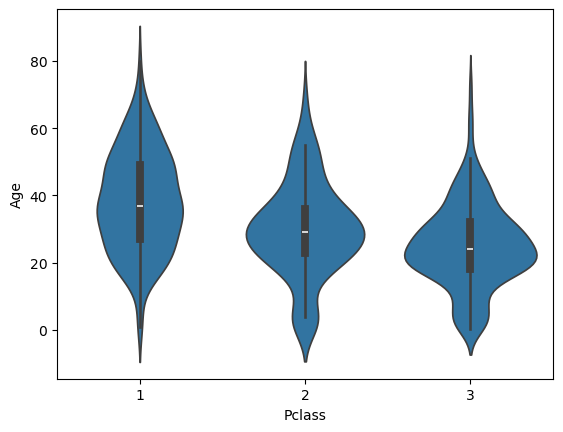

In [76]:
sns.violinplot(x='Pclass',y='Age',data=titanic_df)
plt.show()

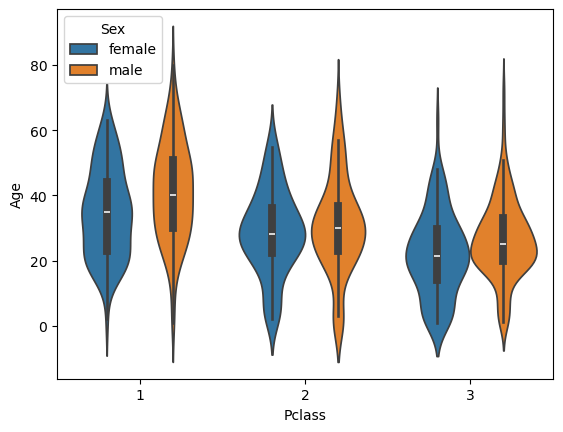

In [77]:
sns.violinplot(x='Pclass',y='Age',hue='Sex',data=titanic_df)
plt.show()

index: 0
index: 1
index: 2


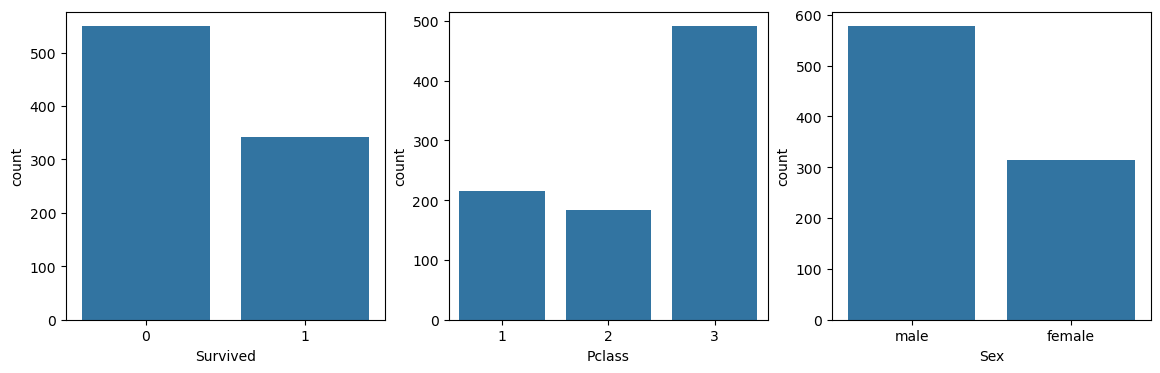

In [82]:
#subplots를 이용하여 시본의 다양한 그래프를 시각화

cat_columns=['Survived','Pclass','Sex']

fig,axs=plt.subplots(nrows=1,ncols=len(cat_columns),figsize=(14,4))

for index,column in enumerate(cat_columns):
    print('index:',index)
    sns.countplot(x=column,data=titanic_df,ax=axs[index])

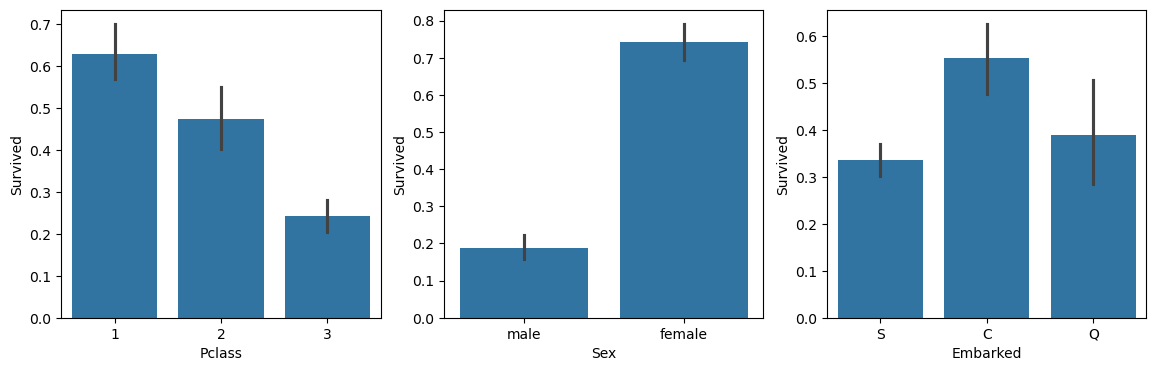

In [84]:
cat_columns=['Pclass','Sex','Embarked']
fig,axs=plt.subplots(nrows=1,ncols=len(cat_columns),figsize=(14,4))

for index,column in enumerate(cat_columns):
    sns.barplot(x=column,y='Survived',data=titanic_df,ax=axs[index])

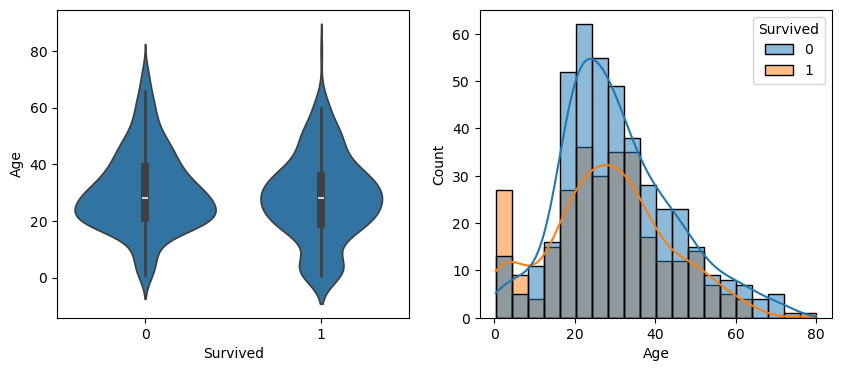

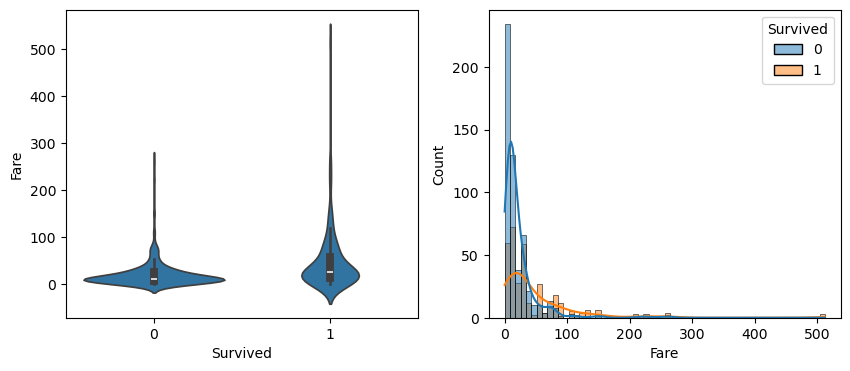

In [86]:
cont_columns=['Age','Fare']
for column in cont_columns:
    fig,axs=plt.subplots(nrows=1,ncols=2,figsize=(10,4))
    sns.violinplot(x='Survived',y=column,data=titanic_df,ax=axs[0])
    sns.histplot(x=column,data=titanic_df,kde=True,hue='Survived',ax=axs[1])

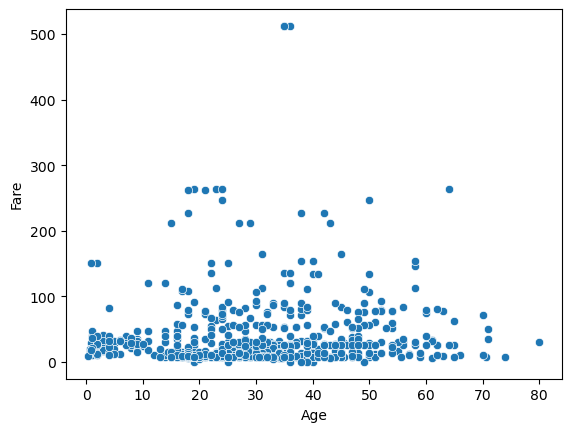

In [88]:
#산점도,스캐터 플롯: 좌표상에 점을 표시히여 변수 간의 관계를 나타냄, x,y축 모두 연속형 숫자
sns.scatterplot(x='Age',y='Fare',data=titanic_df)
plt.show()

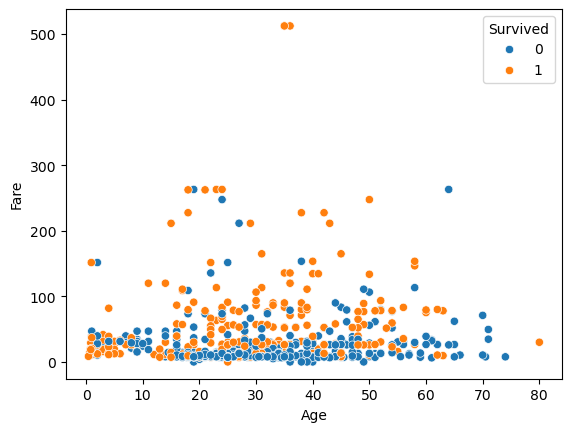

In [90]:
sns.scatterplot(x='Age',y='Fare',hue='Survived',data=titanic_df)
plt.show()

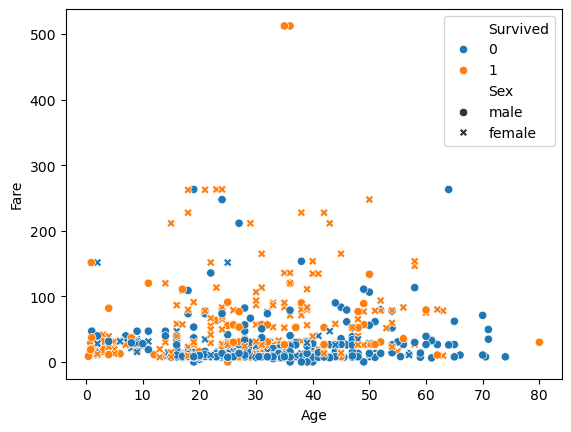

In [91]:
sns.scatterplot(x='Age',y='Fare',hue='Survived',style='Sex',data=titanic_df)
plt.show()

In [92]:
#상관 히트맵: 다수의 속성들 간의 상관계수를 히트맵 형태로 나타낼 수 있다.
corr_df=titanic_df.corr() #숫자형이 아니라서 오류 발생
corr_df

ValueError: could not convert string to float: 'Braund, Mr. Owen Harris'

In [93]:
corr=titanic_df.corr()
sns.heatmap(corr)
plt.show()

ValueError: could not convert string to float: 'Braund, Mr. Owen Harris'

In [94]:
sns.heatmap(corr,annot=True,fmt='.1f',cbar=True)
plt.show()

NameError: name 'corr' is not defined